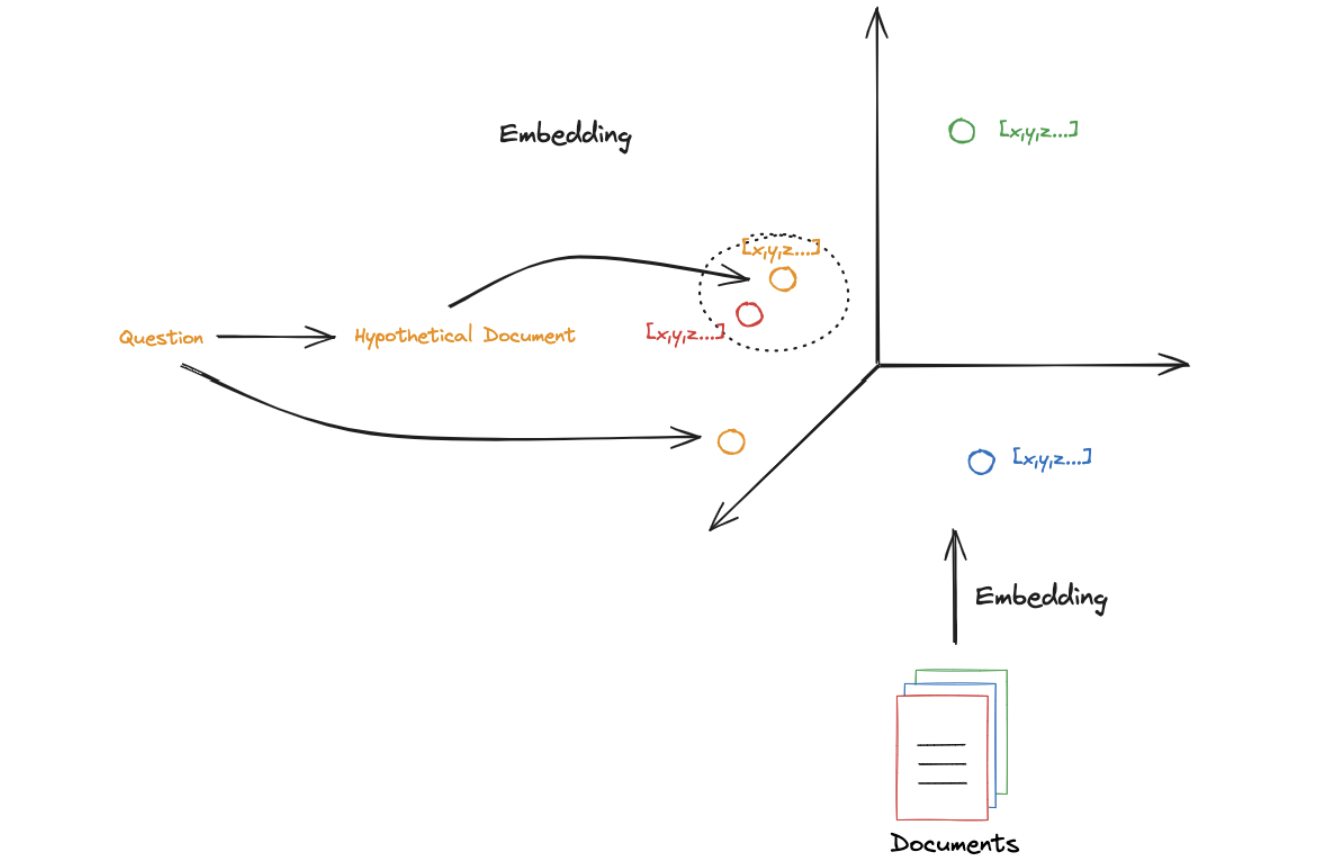

In [1]:
import bs4
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ADV_RAG_KEY")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
blog_docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits, "", len(splits)

([Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and ref

In [3]:
vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"))

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)
retriever 

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000219D1304B10>, search_type='mmr', search_kwargs={'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5})

In [4]:
retriever.invoke("What is task decomposition for LLM agents?")

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=api_key)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x00000219D12D2790>, default_metadata=(), model_kwargs={})

In [6]:
template = """Please write a scientific paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

generate_docs_for_retrieval = (
    prompt_hyde 
    | llm 
    | StrOutputParser() 
)

# Run
question = "What is task decomposition for LLM agents?"
generate_docs_for_retrieval.invoke({"question":question})

"Task decomposition, in the context of Large Language Model (LLM) agents, refers to the strategic process of breaking down a complex, high-level objective into a series of smaller, more manageable, and often interdependent sub-tasks. This process is fundamental for enabling LLM agents to tackle intricate problems that would otherwise overwhelm their direct reasoning capabilities or lead to suboptimal solutions.\n\nAnalogous to human problem-solving, where complex challenges are often addressed by segmenting them into discrete steps, LLM agents employ decomposition to transform an ambiguous or multi-faceted prompt into a structured execution plan. This typically involves the agent first comprehending the overarching goal, then iteratively generating a sequence of logical sub-goals or actions. Each sub-task is designed to be simpler, more specific, and often solvable independently or with fewer reasoning steps than the original task.\n\nThe primary benefits of task decomposition are mult

In [7]:
retrieval_chain = generate_docs_for_retrieval | retriever 
retrieved_docs = retrieval_chain.invoke({"question":question})
retrieved_docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [8]:
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":retrieved_docs,"question":question})

'Task decomposition for LLM agents is the process of breaking down complicated or hard tasks into smaller, simpler, and more manageable steps. This allows the agent to plan ahead and tackle complex problems by addressing individual components.\n\nMethods for task decomposition include:\n*   **Chain of Thought (CoT):** Instructing the LLM to "think step by step" to utilize more test-time computation.\n*   **Tree of Thoughts (ToT):** An extension of CoT that explores multiple reasoning possibilities at each step, generating multiple thoughts per step in a tree structure.\n*   **LLM with simple prompting:** Using prompts like "Steps for XYZ.\\\\n1." or "What are the subgoals for achieving XYZ?".\n*   **Task-specific instructions:** Providing specific guidance, such as "Write a story outline." for a novel-writing task.\n*   **Human inputs:** Incorporating human guidance to define the decomposition.'